In [ ]:
!pip -q install qiskit
!pip -q install qiskit-ibm-runtime
!pip -q install qiskit_aer
!pip -q install qiskit[visualization]
!pip -q install pylatexenc

from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from math import pi, sqrt
from qiskit.visualization import plot_bloch_multivector, plot_histogram
import matplotlib.pyplot as plt
from IPython.display import display


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.5/130.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 131.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


--- Circuit for n=5 and balanced function ---


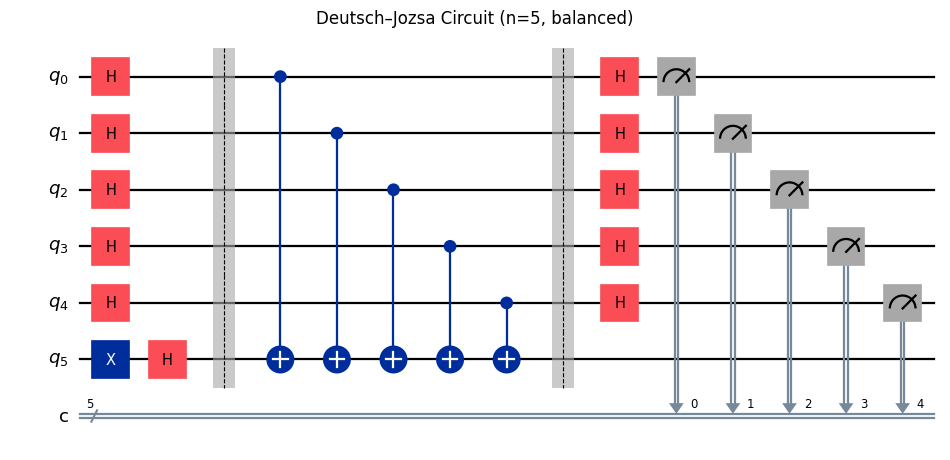


--- Results ---
 > Measurement counts: {'11111': 1024}

--- Decision ---
Result '11111' is nonzero. Function is balanced.


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from itertools import product
%matplotlib inline


def create_dj_oracle(n: int, case: str = "balanced") -> QuantumCircuit:
    oracle_qc = QuantumCircuit(n + 1, name=f"Oracle ({case})")
    if case == "balanced":
        for i in range(n):
            oracle_qc.cx(i, n)
    elif case == "constant":
        pass
    else:
        raise ValueError("case must be 'balanced' or 'constant'")
    return oracle_qc


def create_deutsch_jozsa_circuit(n: int, case: str = "balanced") -> QuantumCircuit:
    qc = QuantumCircuit(n + 1, n)
    qc.h(range(n))
    qc.x(n)
    qc.h(n)
    qc.barrier()
    oracle = create_dj_oracle(n, case)
    qc = qc.compose(oracle)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc


n = 5
function_type = "balanced"

dj_circuit = create_deutsch_jozsa_circuit(n, function_type)
print(f"--- Circuit for n={n} and {function_type} function ---")

fig, ax = plt.subplots(figsize=(12, 6))
dj_circuit.draw(output="mpl", ax=ax, style="iqp")
plt.title(f"Deutsch–Jozsa Circuit (n={n}, {function_type})")
plt.show()

simulator = AerSimulator()
transpiled_circuit = transpile(dj_circuit, simulator)
job = simulator.run(transpiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(transpiled_circuit)

print(f"\n--- Results ---")
print(f" > Measurement counts: {counts}")

most_likely_outcome = max(counts, key=counts.get)
print("\n--- Decision ---")
if all(bit == '0' for bit in most_likely_outcome):
    print(f"Result '{most_likely_outcome}' is zero vector. Function is constant.")
else:
    print(f"Result '{most_likely_outcome}' is nonzero. Function is balanced.")

all_outcomes = [''.join(bits) for bits in product('01', repeat=n)]
for outcome in all_outcomes:
    counts.setdefault(outcome, 0)

hist = plot_histogram(counts, title=f"Results ({function_type} function, n={n})", sort='asc')

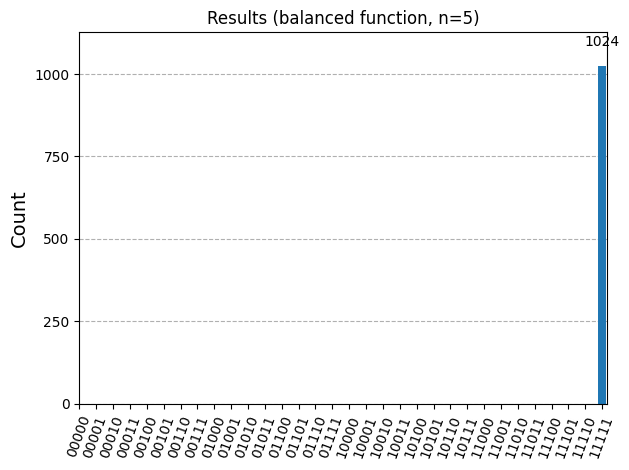

In [ ]:
hist

--- Circuit for n=5 and constant function ---


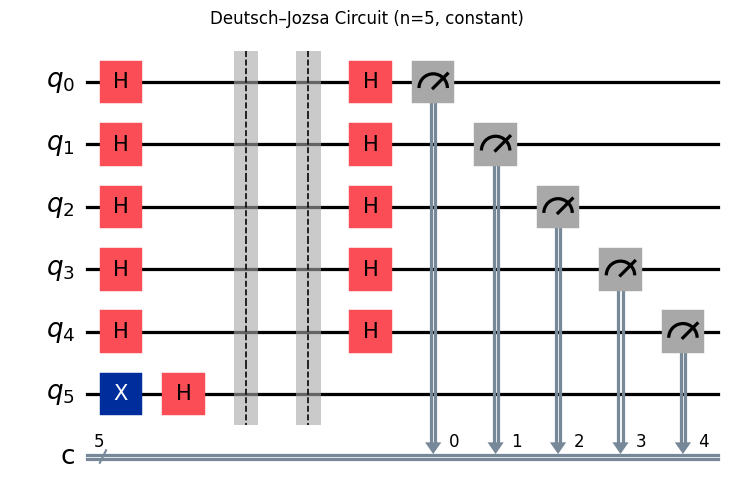


--- Results ---
 > Measurement counts: {'00000': 1024}

--- Decision ---
Result '00000' is zero vector. Function is constant.


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from itertools import product
%matplotlib inline


def create_dj_oracle(n: int, case: str = "balanced") -> QuantumCircuit:
    oracle_qc = QuantumCircuit(n + 1, name=f"Oracle ({case})")
    if case == "balanced":
        for i in range(n):
            oracle_qc.cx(i, n)
    elif case == "constant":
        pass
    else:
        raise ValueError("case must be 'balanced' or 'constant'")
    return oracle_qc


def create_deutsch_jozsa_circuit(n: int, case: str = "balanced") -> QuantumCircuit:
    qc = QuantumCircuit(n + 1, n)
    qc.h(range(n))
    qc.x(n)
    qc.h(n)
    qc.barrier()
    oracle = create_dj_oracle(n, case)
    qc = qc.compose(oracle)
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc


n = 5
function_type = "constant"

dj_circuit = create_deutsch_jozsa_circuit(n, function_type)
print(f"--- Circuit for n={n} and {function_type} function ---")

fig, ax = plt.subplots(figsize=(12, 6))
dj_circuit.draw(output="mpl", ax=ax, style="iqp")
plt.title(f"Deutsch–Jozsa Circuit (n={n}, {function_type})")
plt.show()

simulator = AerSimulator()
transpiled_circuit = transpile(dj_circuit, simulator)
job = simulator.run(transpiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts(transpiled_circuit)

print(f"\n--- Results ---")
print(f" > Measurement counts: {counts}")

most_likely_outcome = max(counts, key=counts.get)
print("\n--- Decision ---")
if all(bit == '0' for bit in most_likely_outcome):
    print(f"Result '{most_likely_outcome}' is zero vector. Function is constant.")
else:
    print(f"Result '{most_likely_outcome}' is nonzero. Function is balanced.")

all_outcomes = [''.join(bits) for bits in product('01', repeat=n)]
for outcome in all_outcomes:
    counts.setdefault(outcome, 0)

hist = plot_histogram(counts, title=f"Results ({function_type} function, n={n})", sort='asc')

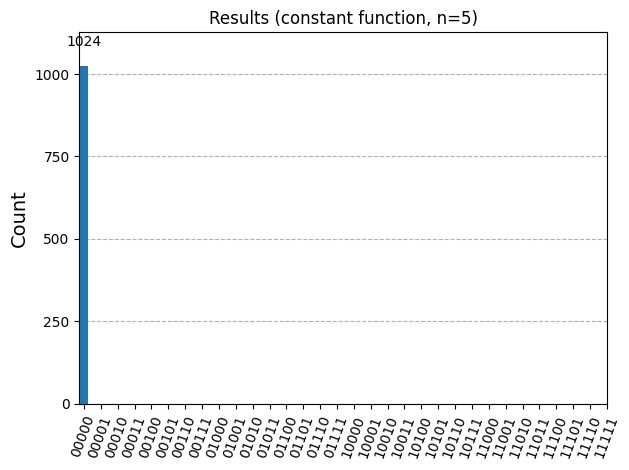

In [ ]:
hist

In [ ]:

def hadamard_product(A, B):
    if len(A) != len(B) or len(A[0]) != len(B[0]):
        raise ValueError("Matrices must be of same dimensions")
    rows = len(A)
    cols = len(A[0])
    C = [[0 for _ in range(cols)] for _ in range(rows)]
    for i in range(rows):
        for j in range(cols):
            C[i][j] = A[i][j] * B[i][j]

    return C


A = [[2, 3, 1],
     [0, 8, -2]]

B = [[3, 1, 4],
     [7, 9, 5]]

C = hadamard_product(A, B)

print("Matrix A:")
for row in A: print(row)

print("\nMatrix B:")
for row in B: print(row)

print("\nHadamard Product (A ∘ B):")
for row in C: print(row)


Matrix A:
[2, 3, 1]
[0, 8, -2]

Matrix B:
[3, 1, 4]
[7, 9, 5]

Hadamard Product (A ∘ B):
[6, 3, 4]
[0, 72, -10]
